In [329]:
from mpl_toolkits import mplot3d
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib
import math
import seaborn as sns
import pandas as pd
from sympy import *
from sympy import Symbol, solveset, S, erf, log, sqrt
init_printing(use_unicode=True)

import scipy.optimize as optimize

# Change the font to Arial
#plt.rcParams['font.family'] = 'Arial'


In [330]:
separable = pd.read_csv('G_strategy_results_nocrossterms_june5.csv').dropna() #pd.read_csv('G_strategy_results_june3.csv').dropna()
separable_highd = pd.read_csv('nobargaining_results_parallel_june6_crossterm_0.csv').dropna()          #pd.read_csv('G_strategy_results_june3.csv').dropna()
positive_crossterms = pd.read_csv('G_strategy_results_pluscrossterms_june3.csv').dropna()
negative_crossterms = pd.read_csv('G_strategy_results_minuscrossterms_june5.csv').dropna()
#negative_crossterms = pd.read_csv('nobargaining_results_parallel_june9_crossterm_-0.1.csv').dropna()

ct_neg_25 = pd.read_csv('nobargaining_results_parallel_june8_crossterm_-0.25.csv').dropna()
ct_pos_25 = pd.read_csv('nobargaining_results_parallel_june8_crossterm_0.25.csv').dropna()
ct_pos_75 = pd.read_csv('nobargaining_results_parallel_june8_crossterm_0.75.csv').dropna()
ct_pos_125 = pd.read_csv('nobargaining_results_parallel_june8_crossterm_1.25.csv').dropna()

In [331]:
def get_grid_plot_data(result_data):
    #define thetaGs and thetaDs as the set that appear in result_data
    thetaGs = np.sort(list(set(result_data['thetaG'])))
    thetaDs = np.sort(list(set(result_data['theta'])))

    ThetaDs, ThetaGs = np.meshgrid(thetaDs, thetaGs)
    beta_1_values = np.zeros(ThetaDs.shape)
    U_G_values = np.zeros(ThetaDs.shape)
    U_D_values = np.zeros(ThetaDs.shape)

    # Create a heatmap of the combinations of thetaDs and thetaGs that are appear in the G_strategy_results dataframe
    for i in range(len(thetaDs)):
        if i % 100 == 0:
            print(i)
        for j in range(len(thetaGs)):
            mini_dataset = result_data[(result_data['theta']==thetaDs[i])&(result_data['thetaG']==thetaGs[j])]
            if len(mini_dataset)>0:
                beta_1_values[j,i] = mini_dataset['beta_1']
                U_G_values[j,i] = mini_dataset['U_G']
                U_D_values[j,i] = mini_dataset['U_D']

    return ThetaDs, ThetaGs, beta_1_values, U_G_values, U_D_values

In [332]:
ThetaDs_neg25, ThetaGs_neg25, beta_1_values_neg25, U_G_values_neg25, U_D_values_neg25 = get_grid_plot_data(ct_neg_25)
ThetaDs_pos25, ThetaGs_pos25, beta_1_values_pos25, U_G_values_pos25, U_D_values_pos25 = get_grid_plot_data(ct_pos_25)
ThetaDs_pos25, ThetaGs_pos75, beta_1_values_pos75, U_G_values_pos75, U_D_values_pos75 = get_grid_plot_data(ct_pos_75)
ThetaDs_pos25, ThetaGs_pos125, beta_1_values_pos125, U_G_values_pos125, U_D_values_pos125 = get_grid_plot_data(ct_pos_125)

0


/var/folders/35/rbf5cr3s6wx53bzp489khqh40000gn/T/ipykernel_10423/1902856209.py:18: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  beta_1_values[j,i] = mini_dataset['beta_1']
/var/folders/35/rbf5cr3s6wx53bzp489khqh40000gn/T/ipykernel_10423/1902856209.py:19: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  U_G_values[j,i] = mini_dataset['U_G']
/var/folders/35/rbf5cr3s6wx53bzp489khqh40000gn/T/ipykernel_10423/1902856209.py:20: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  U_D_values[j,i] = mini_dataset['U_D']


0
0
0


In [333]:
ThetaDs_sep, ThetaGs_sep, beta_1_values_sep, U_G_values_sep, U_D_values_sep = get_grid_plot_data(separable)
print("Done with separable. Beginning separable highd.")
ThetaDs_sephd, ThetaGs_sephd, beta_1_values_sephd, U_G_values_sephd, U_D_values_sephd = get_grid_plot_data(separable_highd)
print("Done with separable. Beginning positive crossterms.")
ThetaDs_pos, ThetaGs_pos, beta_1_values_pos, U_G_values_pos, U_D_values_pos = get_grid_plot_data(positive_crossterms)
print("Done with positive crossterms. Beginning negative crossterms.")
ThetaDs_neg, ThetaGs_neg, beta_1_values_neg, U_G_values_neg, U_D_values_neg = get_grid_plot_data(negative_crossterms)

0


/var/folders/35/rbf5cr3s6wx53bzp489khqh40000gn/T/ipykernel_10423/1902856209.py:18: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  beta_1_values[j,i] = mini_dataset['beta_1']
/var/folders/35/rbf5cr3s6wx53bzp489khqh40000gn/T/ipykernel_10423/1902856209.py:19: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  U_G_values[j,i] = mini_dataset['U_G']
/var/folders/35/rbf5cr3s6wx53bzp489khqh40000gn/T/ipykernel_10423/1902856209.py:20: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  U_D_values[j,i] = mini_dataset['U_D']


100
Done with separable. Beginning separable highd.
0
100
200
300
400
500
Done with separable. Beginning positive crossterms.
0
100
Done with positive crossterms. Beginning negative crossterms.
0
100


In [496]:
def make_four_panel_plot(beta_1_values, U_G_values, U_D_values, ThetaDs, ThetaGs, savefile=None):

    fig, ax = plt.subplots(1,4
                           ,figsize=[22.5,4]#[28,5]
                           , width_ratios=[1,1,1,.8])

    data_for_heatmap = pd.DataFrame({'thetaGs': ThetaGs.flatten(), 'thetaDs': ThetaDs.flatten(), 'beta_1': beta_1_values.flatten()})

    # Round thetaDs and thetaGs to 3 decimal places
    data_for_heatmap['thetaDs'] = data_for_heatmap['thetaDs'].round(3)
    data_for_heatmap['thetaGs'] = data_for_heatmap['thetaGs'].round(3)

    # Filter out thetaG values above 1.3
    data_for_heatmap = data_for_heatmap[data_for_heatmap['thetaGs'] <= 1.3]
    no_reg_data = np.zeros(ThetaDs.shape)
    for i in range(len(ThetaDs)):
        for j in range(len(ThetaGs)):
            if ThetaGs[j,i] > ThetaDs[j,i]:
                no_reg_data[j,i] = 1
    no_reg_data[no_reg_data == 0] = np.nan
    no_reg_data = no_reg_data.T
    no_reg_data = pd.DataFrame(no_reg_data).iloc[::-1]
    # Swap the y axis to be in the correct order

    # Create pivot table for heatmap
    pivot_data = data_for_heatmap.pivot(index='thetaDs', columns='thetaGs', values='beta_1')
   #pivot_data_no_reg = np.isnan(pivot_data)

    # Plot in BLACK anywwhere that beta_1 is <=0
    pivot_data[pivot_data <= 0] = np.nan
    infeasible_data = pivot_data.copy().fillna(0)
    infeasible_data[infeasible_data > 0] = np.nan

    # Invert the y axis
    pivot_data = pivot_data.iloc[::-1]
    infeasible_data = infeasible_data.iloc[::-1]

    # Create heatmap
    sns.heatmap(pivot_data, cmap='RdYlGn', cbar_kws={'label': '$\\beta_1$'}, ax=ax[0])
    # Double the number of x-tick labels by setting xticklabels to half the previous value
    sns.heatmap(infeasible_data, cmap='gray',cbar=False, ax=ax[0], xticklabels = 25, yticklabels = 50)#xticklabels = 25, yticklabels = 50)#xticklabels = 50, yticklabels = 100)

    # Outline in red anywhere that beta_1 is <beta_1 at theta_G = 0 and theta_D = 0
    baseline_beta = pivot_data.loc[0,0]
    print(baseline_beta)
    backfiring_data = pivot_data.copy()
    backfiring_data[backfiring_data >= baseline_beta] = np.nan
    backfiring_data[backfiring_data <= 0] = np.nan
    backfiring_data = backfiring_data.fillna(0)

    # Instead of a heatmap, plot as a contour plot the outline of the backfiring_data. There should be a corresponding entry in the legend for the backfiring region. Make sure the legend populates.
    ax[0].contour(backfiring_data, colors='black', levels=[0], linewidths=1, label='Backfiring')
    ax[0].set_xlabel('Generalist threshold')# ($\\theta_G$)')
    ax[0].set_ylabel('Domain-specialist threshold')# ($\\theta_D$)')
    ax[0].plot([], [], color='black', linewidth=1, label='Backfiring')
    ax[0].set_title('Safety') # ($\\beta_1$)')
    ax[0].legend(loc='lower right')
    # On the second plot, plot the U_G values as a the heatmap data
    
    data_for_heatmap_2 = pd.DataFrame({'thetaGs': ThetaGs.flatten(), 'thetaDs': ThetaDs.flatten(), 'U_G': U_G_values.flatten()})
    data_for_heatmap_2['thetaDs'] = data_for_heatmap_2['thetaDs'].round(3)
    data_for_heatmap_2['thetaGs'] = data_for_heatmap_2['thetaGs'].round(3)
    pivot_data = data_for_heatmap_2.pivot(index='thetaDs', columns='thetaGs', values='U_G')

    pivot_data = pivot_data.iloc[::-1]
    sns.heatmap(pivot_data, cmap='viridis', cbar_kws={'label': '$U_G$'}, ax=ax[1],vmin=0)
    sns.heatmap(infeasible_data, cmap='gray',cbar=False, ax=ax[1], xticklabels = 25, yticklabels = 50)

    # What is the value of the utility at theta_G = 0 and theta_D = 0?
    basline_ug = pivot_data.loc[0,0]
    # Create a contour plot to outline the improvement region
    improvement_data = pivot_data.copy()
    improvement_data[improvement_data <= basline_ug] = 0

    ax[1].contour(improvement_data, colors='white', levels=[0.0], linewidths=1, label='Improvement')
    # Set the colorbar with limits 0, 1.
    ax[1].set_xlabel('Generalist threshold')# ($\\theta_G$)')
    ax[1].set_ylabel('Domain-specialist threshold')# ($\\theta_D$)')
    ax[1].plot([], [], color='white', linewidth=1, label='Improvement')
    ax[1].legend(loc='lower right')


    # On the third plot, plot the U_D values as a the heatmap data
    data_for_heatmap_3 = pd.DataFrame({'thetaGs': ThetaGs.flatten(), 'thetaDs': ThetaDs.flatten(), 'U_D': U_D_values.flatten()})
    data_for_heatmap_3['thetaDs'] = data_for_heatmap_3['thetaDs'].round(3)
    data_for_heatmap_3['thetaGs'] = data_for_heatmap_3['thetaGs'].round(3)
    pivot_data = data_for_heatmap_3.pivot(index='thetaDs', columns='thetaGs', values='U_D')
    pivot_data = pivot_data.iloc[::-1]
    sns.heatmap(pivot_data, cmap='viridis', cbar_kws={'label': '$U_D$'}, ax=ax[2],vmin=0)
    sns.heatmap(infeasible_data, cmap='gray',cbar=False, ax=ax[2], xticklabels = 25, yticklabels = 50)

    # What is the value of the utility at theta_G = 0 and theta_D = 0?
    basline_ud = pivot_data.loc[0,0]
    improvement_data = pivot_data.copy()
    improvement_data[improvement_data <= basline_ud] = 0
    ax[2].contour(improvement_data, colors='white', levels=[0.0], linewidths=1, label='Improvement')
    ax[2].set_xlabel('Generalist threshold')# ($\\theta_G$)')
    ax[2].set_ylabel('Domain-specialist threshold')# ($\\theta_D$)')
    ax[2].plot([], [], color='white', linewidth=1, label='Improvement')
    ax[2].legend(loc='lower right')

    #ax[0].set_title('$\\beta_1$')
    ax[1].set_title('Generalist\'s Utility')# ($U_G$)')
    ax[2].set_title('Domain-specialist\'s Utility')# ($U_D$)')

    # Plot a constant color for all the values in infeasible_data
    feasible_data = pivot_data.copy()
    feasible_data[feasible_data < 0] = np.nan
    feasible_data[feasible_data >= 0] = 1.0

    # Plot the entire x and y axis in yellow constant solid
    # Use fill to fill a polygon
    ax[3].fill([0,1000.25,1000.25,0],[0,0,1000.25,1000.25],color='lightblue', label='Feasible')
    # Plot a line representing the feasible regulations where theta_G = theta_D
    data_for_finalplot = pd.DataFrame({'thetaGs': ThetaGs.flatten()
                                    , 'thetaDs': ThetaDs.flatten()
                                    , 'beta_1': beta_1_values.flatten()
                                    , 'U_G': U_G_values.flatten()
                                    , 'U_D': U_D_values.flatten()})
    data_for_finalplot['backfiring'] = np.logical_and(np.less(data_for_finalplot['beta_1'], baseline_beta), np.greater(data_for_finalplot['beta_1'], 0))
    data_for_finalplot['pareto_improvement'] = np.logical_and(np.greater(data_for_finalplot['U_G'], basline_ug), np.greater(data_for_finalplot['U_D'], basline_ud))

    # Plot the pareto improvement region
    pivot_data_pareto = data_for_finalplot.pivot(index='thetaDs', columns='thetaGs', values='pareto_improvement')
    pivot_data_pareto = pivot_data_pareto.iloc[::-1]
    ax[3].contourf(pivot_data_pareto, colors='green', levels=[0.5,1], label='Mutualism')
    ax[3].fill([], [], color='green', linewidth=1, label='Mutualism')
    #Plot the backfiring region
    pivot_data_backfiring = data_for_finalplot.pivot(index='thetaDs', columns='thetaGs', values='backfiring')
    #print(pivot_data_backfiring.head())
    pivot_data_backfiring = pivot_data_backfiring.iloc[::-1]
    # Fill in the contour with a color
    ax[3].contourf(pivot_data_backfiring, colors='maroon', levels=[0.5,1], label='Backfiring')
    ax[3].fill([], [], color='maroon', linewidth=1, label='Backfiring')

    ax[3].legend(loc='lower right')

    # Plot black for all values in the infeasible set
    sns.heatmap(infeasible_data, cmap='gray',cbar=False, ax=ax[3], xticklabels = 25, yticklabels = 50)
    ax[3].set_xlabel('Generalist threshold') # ($\\theta_G$)')
    ax[3].set_ylabel('Domain-specialist threshold') # ($\\theta_D$)')
    ax[3].set_title('Feasible Regulatory Regimes')

    # Remove axis labels from all colorbars
    cbar = ax[0].collections[0].colorbar
    cbar.set_label('')
    cbar = ax[1].collections[0].colorbar
    cbar.set_label('')
    cbar = ax[2].collections[0].colorbar
    cbar.set_label('')

    #make yticklabels horizontal
    ax[0].set_yticklabels(ax[0].get_yticklabels(), rotation=0)
    ax[0].set_xticklabels(ax[0].get_xticklabels(), rotation=0)
    ax[1].set_yticklabels(ax[1].get_yticklabels(), rotation=0)
    ax[1].set_xticklabels(ax[1].get_xticklabels(), rotation=0)
    ax[2].set_yticklabels(ax[2].get_yticklabels(), rotation=0)
    ax[2].set_xticklabels(ax[2].get_xticklabels(), rotation=0)
    ax[3].set_yticklabels(ax[3].get_yticklabels(), rotation=0)
    ax[3].set_xticklabels(ax[3].get_xticklabels(), rotation=0)

    #Plot in white the no_reg_data
    #ax[0].contourf(no_reg_data, colors='gray', levels=[0.5,1], cbar=False)
    #ax[1].contourf(no_reg_data, colors='gray', levels=[0.5,1], cbar=False)
    #ax[2].contourf(no_reg_data, colors='gray', levels=[0.5,1], cbar=False)
    #ax[3].contourf(no_reg_data, colors='gray', levels=[0.5,1], cbar=False)

    if savefile is not None:
        plt.savefig(savefile, dpi=300, bbox_inches='tight')


0.5


/var/folders/35/rbf5cr3s6wx53bzp489khqh40000gn/T/ipykernel_10423/4069935933.py:52: UserWarning: The following kwargs were not used by contour: 'label'
  ax[0].contour(backfiring_data, colors='black', levels=[0], linewidths=1, label='Backfiring')
/var/folders/35/rbf5cr3s6wx53bzp489khqh40000gn/T/ipykernel_10423/4069935933.py:75: UserWarning: The following kwargs were not used by contour: 'label'
  ax[1].contour(improvement_data, colors='white', levels=[0.0], linewidths=1, label='Improvement')
/var/folders/35/rbf5cr3s6wx53bzp489khqh40000gn/T/ipykernel_10423/4069935933.py:96: UserWarning: The following kwargs were not used by contour: 'label'
  ax[2].contour(improvement_data, colors='white', levels=[0.0], linewidths=1, label='Improvement')
/var/folders/35/rbf5cr3s6wx53bzp489khqh40000gn/T/ipykernel_10423/4069935933.py:126: UserWarning: The following kwargs were not used by contour: 'label'
  ax[3].contourf(pivot_data_pareto, colors='green', levels=[0.5,1], label='Mutualism')
/var/folders/35

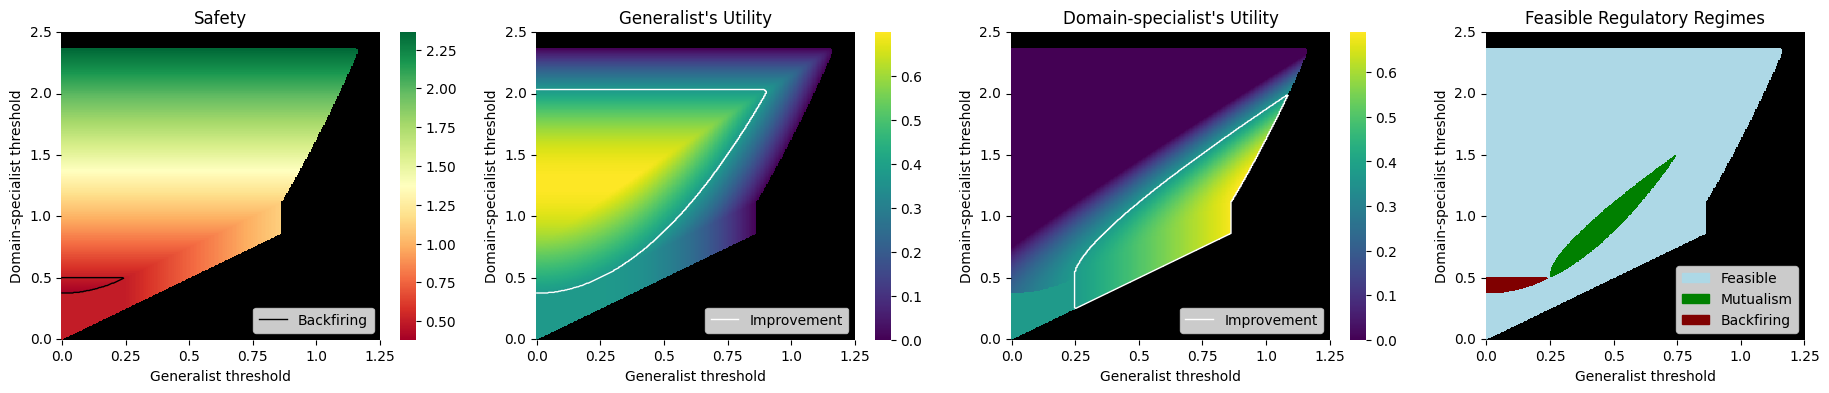

In [495]:
# Make four panel plot for the separable case
make_four_panel_plot(beta_1_values_sephd, U_G_values_sephd, U_D_values_sephd, ThetaDs_sephd, ThetaGs_sephd, savefile='separable_highd_fourpanel.png')

0.4545454545454546


/var/folders/35/rbf5cr3s6wx53bzp489khqh40000gn/T/ipykernel_10423/1075619002.py:52: UserWarning: The following kwargs were not used by contour: 'label'
  ax[0].contour(backfiring_data, colors='black', levels=[0], linewidths=1, label='Backfiring')
/var/folders/35/rbf5cr3s6wx53bzp489khqh40000gn/T/ipykernel_10423/1075619002.py:75: UserWarning: The following kwargs were not used by contour: 'label'
  ax[1].contour(improvement_data, colors='white', levels=[0.0], linewidths=1, label='Improvement')
/var/folders/35/rbf5cr3s6wx53bzp489khqh40000gn/T/ipykernel_10423/1075619002.py:96: UserWarning: The following kwargs were not used by contour: 'label'
  ax[2].contour(improvement_data, colors='white', levels=[0.0], linewidths=1, label='Improvement')
/var/folders/35/rbf5cr3s6wx53bzp489khqh40000gn/T/ipykernel_10423/1075619002.py:126: UserWarning: The following kwargs were not used by contour: 'label'
  ax[3].contourf(pivot_data_pareto, colors='green', levels=[0.5,1], label='Mutualism')
/var/folders/35

0.5


/var/folders/35/rbf5cr3s6wx53bzp489khqh40000gn/T/ipykernel_10423/1075619002.py:52: UserWarning: The following kwargs were not used by contour: 'label'
  ax[0].contour(backfiring_data, colors='black', levels=[0], linewidths=1, label='Backfiring')
/var/folders/35/rbf5cr3s6wx53bzp489khqh40000gn/T/ipykernel_10423/1075619002.py:75: UserWarning: The following kwargs were not used by contour: 'label'
  ax[1].contour(improvement_data, colors='white', levels=[0.0], linewidths=1, label='Improvement')
/var/folders/35/rbf5cr3s6wx53bzp489khqh40000gn/T/ipykernel_10423/1075619002.py:96: UserWarning: The following kwargs were not used by contour: 'label'
  ax[2].contour(improvement_data, colors='white', levels=[0.0], linewidths=1, label='Improvement')
/var/folders/35/rbf5cr3s6wx53bzp489khqh40000gn/T/ipykernel_10423/1075619002.py:126: UserWarning: The following kwargs were not used by contour: 'label'
  ax[3].contourf(pivot_data_pareto, colors='green', levels=[0.5,1], label='Mutualism')
/var/folders/35

0.5555555555555556


/var/folders/35/rbf5cr3s6wx53bzp489khqh40000gn/T/ipykernel_10423/1075619002.py:52: UserWarning: The following kwargs were not used by contour: 'label'
  ax[0].contour(backfiring_data, colors='black', levels=[0], linewidths=1, label='Backfiring')
/var/folders/35/rbf5cr3s6wx53bzp489khqh40000gn/T/ipykernel_10423/1075619002.py:75: UserWarning: The following kwargs were not used by contour: 'label'
  ax[1].contour(improvement_data, colors='white', levels=[0.0], linewidths=1, label='Improvement')
/var/folders/35/rbf5cr3s6wx53bzp489khqh40000gn/T/ipykernel_10423/1075619002.py:96: UserWarning: The following kwargs were not used by contour: 'label'
  ax[2].contour(improvement_data, colors='white', levels=[0.0], linewidths=1, label='Improvement')
/var/folders/35/rbf5cr3s6wx53bzp489khqh40000gn/T/ipykernel_10423/1075619002.py:126: UserWarning: The following kwargs were not used by contour: 'label'
  ax[3].contourf(pivot_data_pareto, colors='green', levels=[0.5,1], label='Mutualism')
/var/folders/35

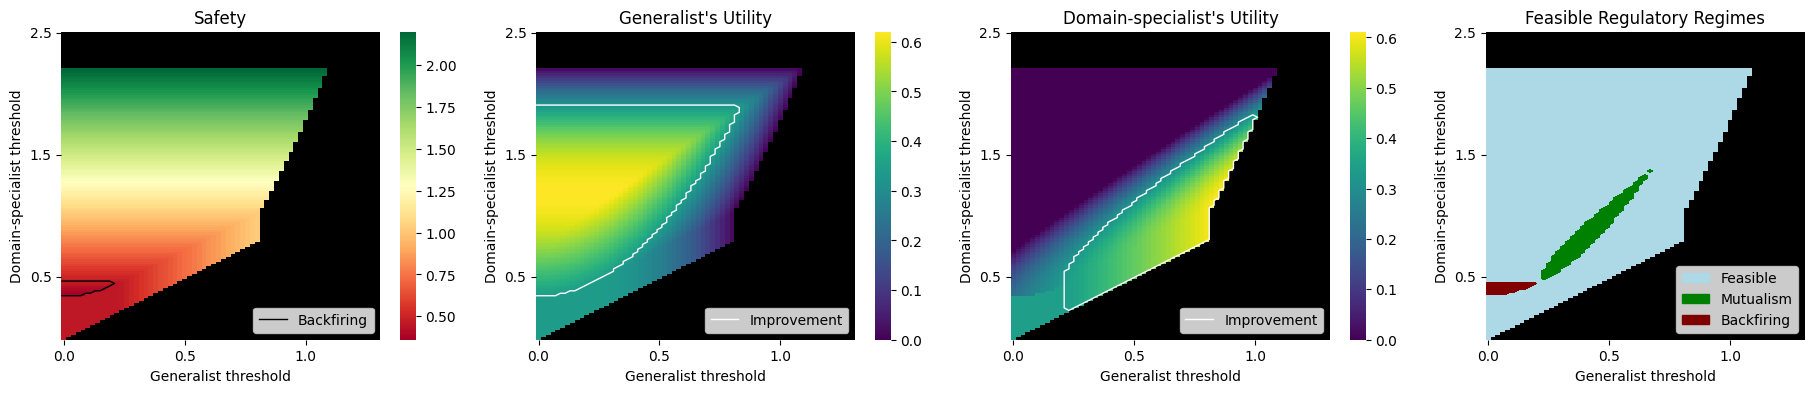

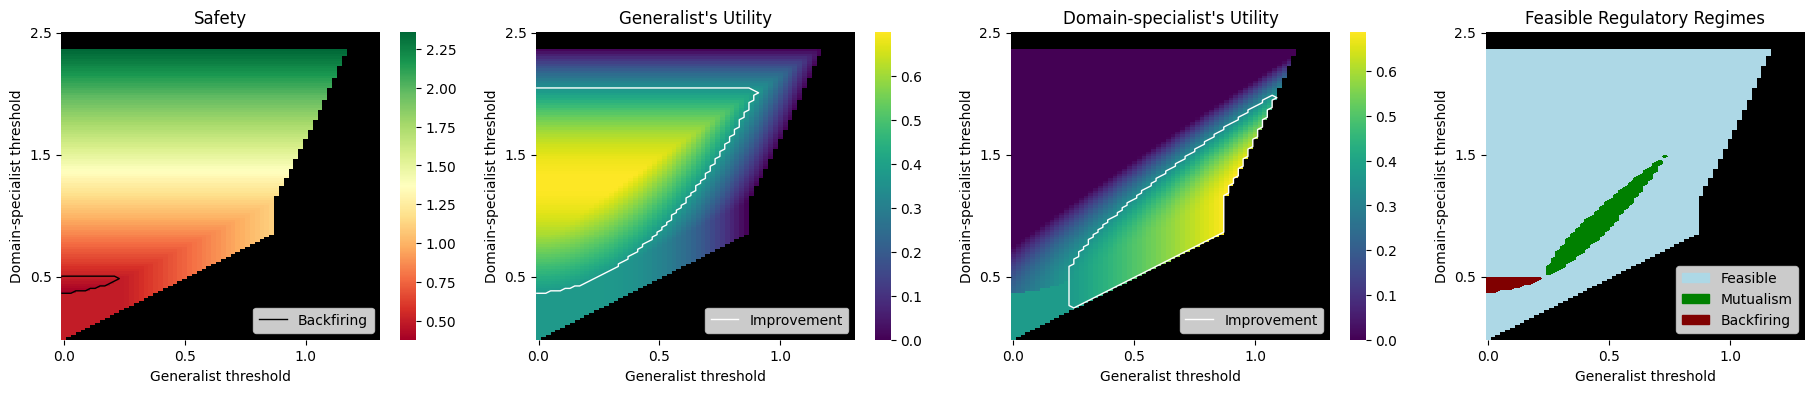

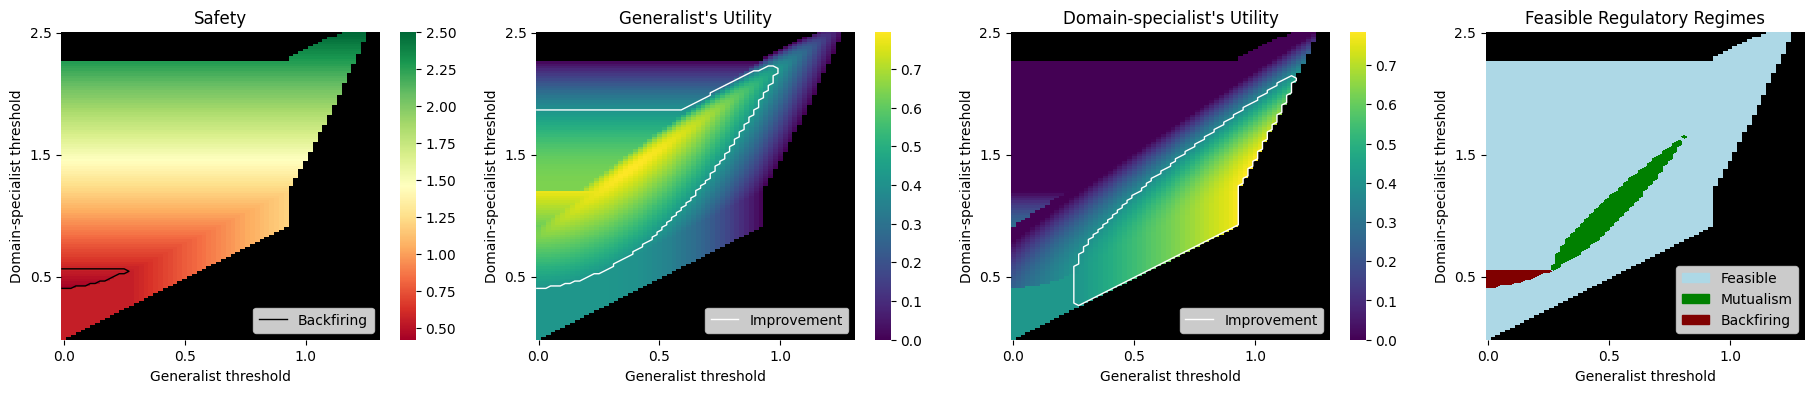

In [498]:
# Make four panel plot for the positive crossterms case
make_four_panel_plot(beta_1_values_pos, U_G_values_pos, U_D_values_pos, ThetaDs_pos, ThetaGs_pos, savefile='positive_crossterms_fourpanel_june9.png')
# Make four panel plot for the separable case
make_four_panel_plot(beta_1_values_sep, U_G_values_sep, U_D_values_sep, ThetaDs_sep, ThetaGs_sep)
# Make four panel plot for the negative crossterms case
make_four_panel_plot(beta_1_values_neg, U_G_values_neg, U_D_values_neg, ThetaDs_neg, ThetaGs_neg, savefile='negative_crossterms_fourpanel_june9.png')

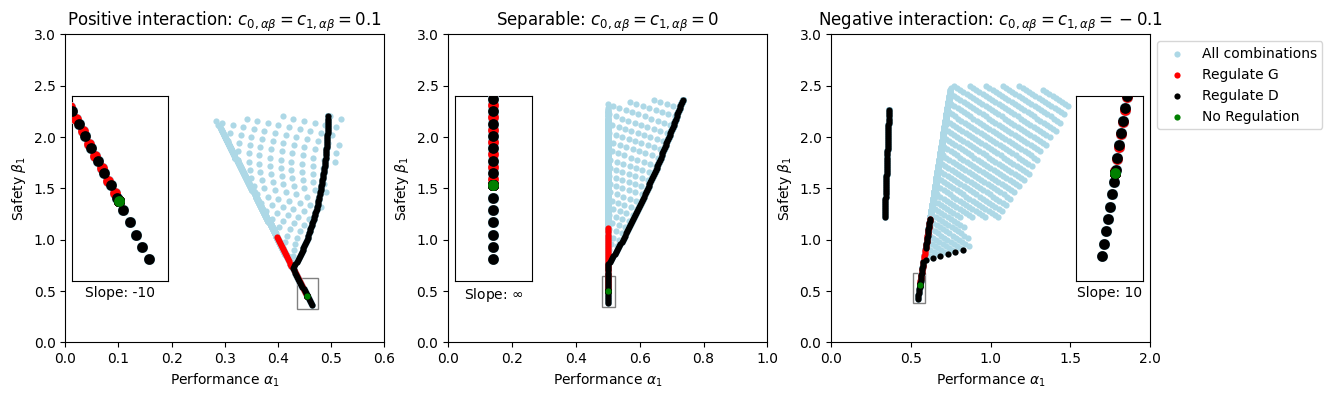

In [335]:
# Plot all attainable beta_0, beta_1 pairs
fig, ax =plt.subplots(1, 3, figsize=[14,4])

def plot_attributes(dataset, ax, size=20):
    ax.scatter(dataset['alpha_1'],dataset['beta_1'],linewidth=0,label='All combinations',color='lightblue', s=size, zorder = 100)
    ax.scatter(dataset[dataset['theta']==dataset['thetaG']]['alpha_1'],dataset[dataset['theta']==dataset['thetaG']]['beta_1'],linewidth=0,label='Regulate G',color='red', s=size, zorder = 100)
    ax.scatter(dataset[dataset['thetaG']==0]['alpha_1'],dataset[dataset['thetaG']==0]['beta_1'],linewidth=0,label='Regulate D',color='black', s=size, zorder = 100)
    ax.scatter(dataset[(dataset['theta']==0)&(dataset['thetaG']==0)]['alpha_1'],dataset[(dataset['theta']==0)&(dataset['thetaG']==0)]['beta_1'],linewidth=0,label='No Regulation',color='green', s=size, zorder = 100)
    ax.set_xlabel('Performance $\\alpha_1$')

plot_attributes(positive_crossterms, ax[0])
plot_attributes(separable, ax[1])
plot_attributes(negative_crossterms, ax[2])

ax[0].set_title('Positive interaction: $c_{0,\\alpha\\beta}=c_{1,\\alpha\\beta}=0.1$')
ax[1].set_title('Separable: $c_{0,\\alpha\\beta}=c_{1,\\alpha\\beta}=0$')
ax[2].set_title('Negative interaction: $c_{0,\\alpha\\beta}=c_{1,\\alpha\\beta}=-0.1$')

ax[0].set_xlabel('Performance $\\alpha_1$')
ax[0].set_ylabel('Safety $\\beta_1$')
ax[1].set_ylabel('Safety $\\beta_1$')
ax[2].set_ylabel('Safety $\\beta_1$')
ax[2].legend(bbox_to_anchor=[1,1])

ax[2].set_xlim([0,2])
ax[2].set_ylim([0,3])
ax[1].set_xlim([0,1])
ax[1].set_ylim([0,3])
ax[0].set_xlim([0,.6])
ax[0].set_ylim([0,3])

#ax[0].set_xlim([0,1.6])

#ax[1].set_xlim([0,1.6])
##
#ax[0].grid(zorder=0)
#ax[1].grid(zorder=0)
#ax[2].grid(zorder=0)

#Create a zoom-in box for the first plot. It should zoom in on the square x=[0.425,0.475] and y=[0.3,0.55].
# Create zoom-in box for the first plot
from mpl_toolkits.axes_grid1.inset_locator import zoomed_inset_axes, mark_inset

# Create inset axes for zoom

# Set the location of the zoomed inset axis using bbox_to_anchor
# Adjust tick label positioning to prevent overlap

axins = zoomed_inset_axes(ax[0], loc=6, zoom=6)  # zoom factor of 3, location upper right
plot_attributes(positive_crossterms, axins,size=20*3)
# Set the limits for the zoom-in region
axins.set_xlim(0.44, 0.47)
axins.set_ylim(0.325, 0.625)
axins.set_xticks([])#[0.44, 0.45, 0.46, 0.47])
#axins.set_xticklabels(['.44', '.45', '.46', '.47'])
axins.set_yticks([])#[0.4,.5])
#axins.set_yticklabels(['.4', '.5'])
#axins.set_xlabel("")
axins.set_xlabel("Slope: -10")
axins.grid()
# Mark the inset region on the main plot with a rectangle
from matplotlib.patches import Rectangle
rect = Rectangle((0.435, 0.325), 0.04, 0.3, linewidth=1, edgecolor='gray', facecolor='none')
ax[0].add_patch(rect)

axins = zoomed_inset_axes(ax[1], loc=6, zoom=6)  # zoom factor of 3, location upper right
plot_attributes(separable, axins,size=20*3)
# Set the limits for the zoom-in region
axins.set_xlim(.5-0.02,.5+0.02) #(0.475, 0.525)
axins.set_ylim(0.325+.02, 0.625+.02)
axins.set_xticks([])#[0.44, 0.45, 0.46, 0.47])
#axins.set_xticklabels(['.44', '.45', '.46', '.47'])
axins.set_yticks([])#[0.4,.5])
#axins.set_yticklabels(['.4', '.5'])
#axins.set_xlabel("")
axins.set_xlabel("Slope: $\infty$")
axins.grid()
# Mark the inset region on the main plot with a rectangle
from matplotlib.patches import Rectangle
rect = Rectangle((.5-0.0175, 0.325+.02), 0.02*2, 0.3, linewidth=1, edgecolor='gray', facecolor='none')
ax[1].add_patch(rect)

#mark_inset(ax[0], axins, loc1=None, loc2=None, fc="none", ec="0.5")


axins = zoomed_inset_axes(ax[2], loc=5, zoom=6)  # zoom factor of 3, location upper right
plot_attributes(negative_crossterms, axins,size=20*3)
# Set the limits for the zoom-in region
axins.set_xlim(0.515, 0.585)
axins.set_ylim(0.38, 0.68)
axins.set_xticks([])#[0.44, 0.45, 0.46, 0.47])
#axins.set_xticklabels(['.44', '.45', '.46', '.47'])
axins.set_yticks([])#[0.4,.5])
#axins.set_yticklabels(['.4', '.5'])
#axins.set_xlabel("")
axins.set_xlabel("Slope: 10")
axins.grid()
# Mark the inset region on the main plot with a rectangle
from matplotlib.patches import Rectangle
rect = Rectangle((0.515, 0.38), 0.07, 0.3, linewidth=1, edgecolor='gray', facecolor='none')
ax[2].add_patch(rect)


#plt.savefig('alpha_beta_scatter_crossterms_nobargaining_june8.png', dpi=300, bbox_inches='tight')


In [ ]:
# Plot the backfiring in just the safety space.

fig, ax = plt.subplots(1, 1, figsize=[14,4])

fig, ax = plt.subplots(1, 1, figsize=[14,4])



<Axes: xlabel='theta', ylabel='alpha_1'>

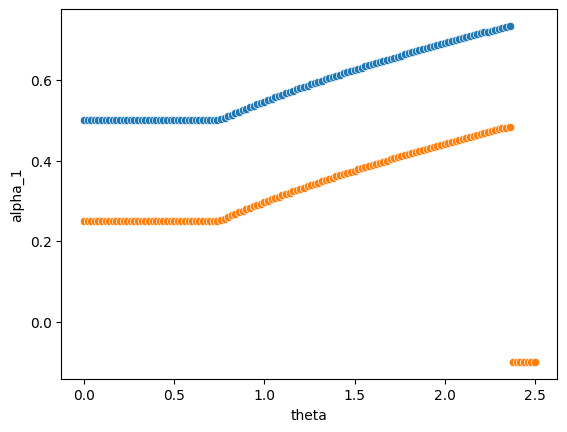

In [345]:
sns.scatterplot(data=separable[separable['thetaG']==0], y='alpha_1', x='theta')
sns.scatterplot(data=separable[separable['thetaG']==0], y='alpha_0', x='theta')

,Unnamed: 0,C0,C1,r,delta,theta,thetaG,alpha_0,alpha_1,beta_1,U_G,U_D,Gstrategy,Dstrategy,backfiring_flag,beta_0
0,0,[[1 0]\n [0 1]],[[1 0]\n [0 1]],[1 1],0.5,0.00,0.0,0.25,0.5,0.5,0.375,0.375,unconstrained,unconstrained,0.0,0.25
1,1,[[1 0]\n [0 1]],[[1 0]\n [0 1]],[1 1],0.5,0.02,0.0,0.25,0.5,0.5,0.375,0.375,unconstrained,unconstrained,0.0,0.25
2,2,[[1 0]\n [0 1]],[[1 0]\n [0 1]],[1 1],0.5,0.04,0.0,0.25,0.5,0.5,0.375,0.375,unconstrained,unconstrained,0.0,0.25
3,3,[[1 0]\n [0 1]],[[1 0]\n [0 1]],[1 1],0.5,0.06,0.0,0.25,0.5,0.5,0.375,0.375,unconstrained,unconstrained,0.0,0.25
4,4,[[1 0]\n [0 1]],[[1 0]\n [0 1]],[1 1],0.5,0.08,0.0,0.25,0.5,0.5,0.375,0.375,unconstrained,unconstrained,0.0,0.25
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6721,6721,[[1 0]\n [0 1]],[[1 0]\n [0 1]],[1 1],0.5,2.42,1.5,-0.10,-0.1,-0.1,-0.100,-0.100,abstain,abstain,0.0,-0.10
6722,6722,[[1 0]\n [0 1]],[[1 0]\n [0 1]],[1 1],0.5,2.44,1.5,-0.10,-0.1,-0.1,-0.100,-0.100,abstain,abstain,0.0,-0.10
6723,6723,[[1 0]\n [0 1]],[[1 0]\n [0 1]],[1 1],0.5,2.46,1.5,-0.10,-0.1,-0.1,-0.100,-0.100,abstain,abstain,0.0,-0.10
6724,6724,[[1 0]\n [0 1]],[[1 0]\n [0 1]],[1 1],0.5,2.48,1.5,-0.10,-0.1,-0.1,-0.100,-0.100,abstain,abstain,0.0,-0.10


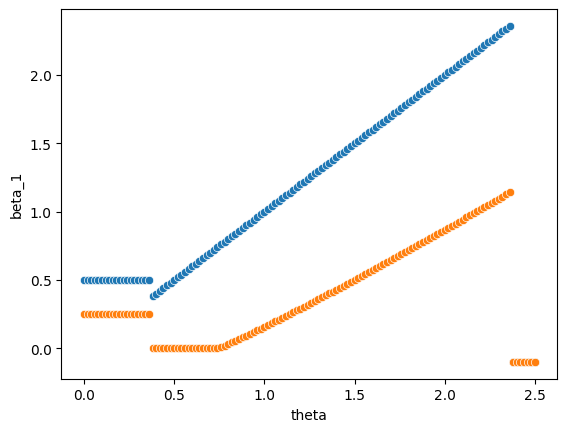

In [344]:
sns.scatterplot(data=separable[separable['thetaG']==0], y='beta_1', x='theta')
sns.scatterplot(data=separable[separable['thetaG']==0], y='beta_0', x='theta')

#sns.lineplot(separable, y='beta_1', x='theta')
separable

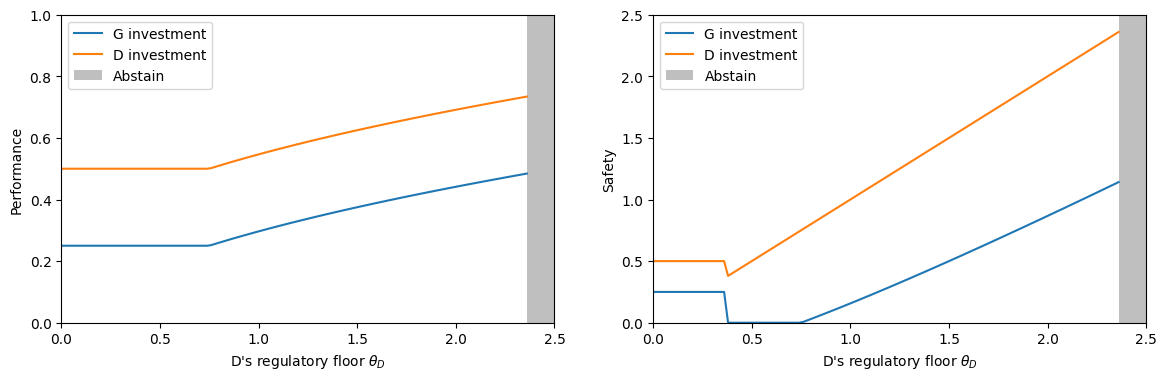

In [393]:
fig, ax = plt.subplots(1, 2, figsize=[14,4])

# On the left, plot a lineplot of theta versus the alpha_0 and alpha_1 for the separable case.
# Only plot the positive y values
sns.lineplot(data=separable[(separable['thetaG']==0)&(separable['alpha_0']>=0)], y='alpha_0', x='theta', ax=ax[0], label='G investment')
sns.lineplot(data=separable[(separable['thetaG']==0)&(separable['alpha_1']>=0)], y='alpha_1', x='theta', ax=ax[0], label='D investment')

# On the right, plot a lineplot of theta versus the beta_0 and beta_1 for the separable case.
sns.lineplot(data=separable[(separable['thetaG']==0)&(separable['beta_0']>=0)], y='beta_0', x='theta', ax=ax[1], label='G investment')
sns.lineplot(data=separable[(separable['thetaG']==0)&(separable['beta_1']>=0)], y='beta_1', x='theta', ax=ax[1], label='D investment')

# bounds of abstain region
abstain_lower = separable[separable['alpha_0']>=0]['theta'].max()
abstain_upper = separable[separable['alpha_0']<0]['theta'].max()
# Plot the theta values where the alpha_0 and alpha_1 are negative as a gray band
theta_neg = list(separable[separable['alpha_0']<0]['theta'])    
ax[0].fill_betweenx([0,2.5],abstain_lower, abstain_upper, color='gray', alpha=0.5,linewidth=0, label='Abstain')
theta_neg = list(separable[separable['alpha_1']<0]['theta'])
ax[1].fill_betweenx([0,2.5],abstain_lower, abstain_upper, color='gray', alpha=0.5,linewidth=0, label='Abstain')

# Plot the band of theta values where backfiring occurs
#anarchy_beta_1 = separable[(separable['theta']==0)&(separable['thetaG']==0)]['beta_1'].mean()
#backfiring_lower = separable[separable['beta_1']<anarchy_beta_1]['theta'].min()
#backfiring_upper = separable[separable['beta_1']<anarchy_beta_1]['theta'].max()
#ax[1].fill_betweenx([0,2.5],backfiring_lower, backfiring_upper, color='red', alpha=0.5,linewidth=0, label='Backfiring')

# Set the x-axis limits to 0 to 1
ax[0].set_xlim(0, 2.5)
ax[0].set_ylim([0, 1])

ax[1].set_xlim(0, 2.5)
ax[1].set_ylim([0, 2.5])

ax[0].set_xlabel('D\'s regulatory floor $\\theta_D$')
ax[1].set_xlabel('D\'s regulatory floor $\\theta_D$')

ax[0].set_ylabel('Performance') 
ax[1].set_ylabel('Safety')

ax[0].legend()
ax[1].legend()



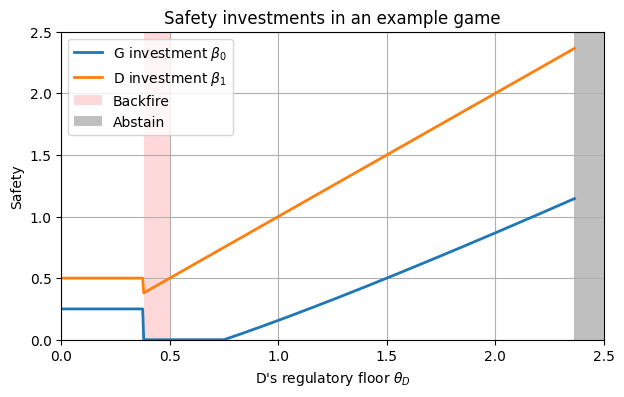

In [429]:
# Repeat the plot above but only the beta_1 and beta_0 values one.
fig, ax = plt.subplots(1, 1, figsize=[7,4])

sns.lineplot(data=separable_highd[(separable_highd['thetaG']==0)&(separable_highd['beta_0']>=0)], y='beta_0', x='theta', ax=ax, label='G investment $\\beta_0$', linewidth=2)
sns.lineplot(data=separable_highd[(separable_highd['thetaG']==0)&(separable_highd['beta_1']>=0)], y='beta_1', x='theta', ax=ax, label='D investment $\\beta_1$', linewidth=2)

ax.set_xlabel('D\'s regulatory floor $\\theta_D$')
ax.set_ylabel('Safety')

# Fill the band regions where beta_1 is less than 0.5
backfire_lower = separable_highd[(separable_highd['thetaG']==0)&(separable_highd['beta_1']<0.5)]['theta'].min()
backfire_upper = separable_highd[(separable_highd['thetaG']==0)&(separable_highd['beta_1']>0.5)]['theta'].min()
ax.fill_betweenx([0,2.5],backfire_lower, backfire_upper, color='red', alpha=0.15,linewidth=0, label='Backfire')

# Abstain region
abstain_lower = separable_highd[separable_highd['beta_0']>=0]['theta'].max()
abstain_upper = separable_highd[separable_highd['beta_0']<0]['theta'].max()
ax.fill_betweenx([0,2.5],abstain_lower, abstain_upper, color='gray', alpha=0.5,linewidth=0, label='Abstain')


ax.set_xlim(0, 2.5)
ax.set_ylim([0, 2.5])

ax.set_title('Safety investments in an example game')
ax.grid()
ax.legend(loc = 'upper left')

plt.savefig('safety_investments_example_game_jun9.png', dpi=300, bbox_inches='tight')


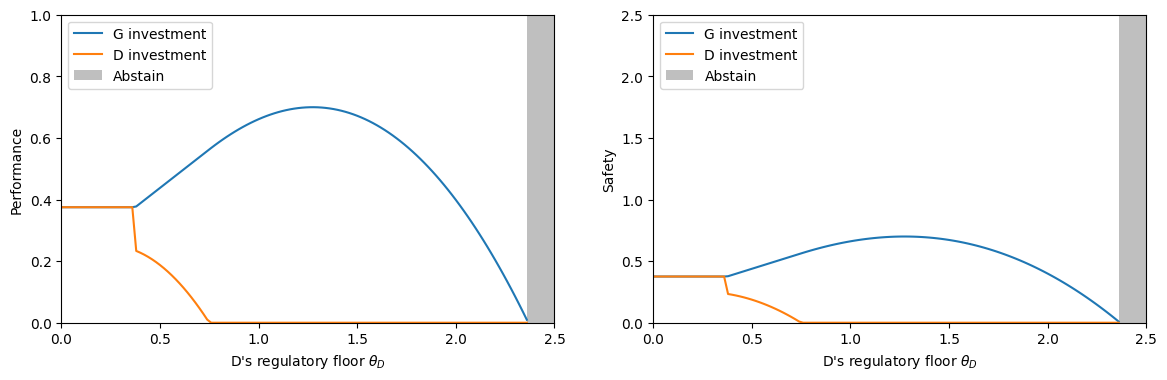

In [394]:
fig, ax = plt.subplots(1, 2, figsize=[14,4])

# On the left, plot a lineplot of theta versus the alpha_0 and alpha_1 for the separable case.
# Only plot the positive y values
sns.lineplot(data=separable[(separable['thetaG']==0)&(separable['alpha_0']>=0)], y='U_G', x='theta', ax=ax[0], label='G investment')
sns.lineplot(data=separable[(separable['thetaG']==0)&(separable['alpha_1']>=0)], y='U_D', x='theta', ax=ax[0], label='D investment')

# On the right, plot a lineplot of theta versus the beta_0 and beta_1 for the separable case.
sns.lineplot(data=separable[(separable['thetaG']==0)&(separable['beta_0']>=0)], y='U_G', x='theta', ax=ax[1], label='G investment')
sns.lineplot(data=separable[(separable['thetaG']==0)&(separable['beta_1']>=0)], y='U_D', x='theta', ax=ax[1], label='D investment')

# bounds of abstain region
abstain_lower = separable[separable['alpha_0']>=0]['theta'].max()
abstain_upper = separable[separable['alpha_0']<0]['theta'].max()
# Plot the theta values where the alpha_0 and alpha_1 are negative as a gray band
theta_neg = list(separable[separable['alpha_0']<0]['theta'])    
ax[0].fill_betweenx([0,2.5],abstain_lower, abstain_upper, color='gray', alpha=0.5,linewidth=0, label='Abstain')
theta_neg = list(separable[separable['alpha_1']<0]['theta'])
ax[1].fill_betweenx([0,2.5],abstain_lower, abstain_upper, color='gray', alpha=0.5,linewidth=0, label='Abstain')

# Plot the band of theta values where backfiring occurs
#anarchy_beta_1 = separable[(separable['theta']==0)&(separable['thetaG']==0)]['beta_1'].mean()
#backfiring_lower = separable[separable['beta_1']<anarchy_beta_1]['theta'].min()
#backfiring_upper = separable[separable['beta_1']<anarchy_beta_1]['theta'].max()
#ax[1].fill_betweenx([0,2.5],backfiring_lower, backfiring_upper, color='red', alpha=0.5,linewidth=0, label='Backfiring')

# Set the x-axis limits to 0 to 1
ax[0].set_xlim(0, 2.5)
ax[0].set_ylim([0, 1])

ax[1].set_xlim(0, 2.5)
ax[1].set_ylim([0, 2.5])

ax[0].set_xlabel('D\'s regulatory floor $\\theta_D$')
ax[1].set_xlabel('D\'s regulatory floor $\\theta_D$')

ax[0].set_ylabel('Performance') 
ax[1].set_ylabel('Safety')

ax[0].legend()
ax[1].legend()

<Axes: xlabel='theta', ylabel='U_G'>

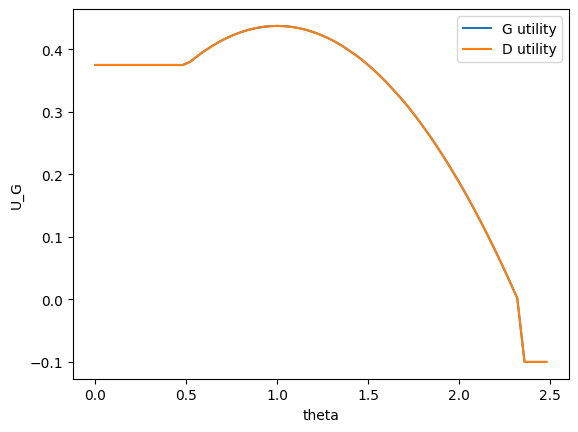

In [504]:
data_for_utility_plotting = separable[separable['theta']==2*separable['thetaG']]
data_for_utility_plotting

sns.lineplot(data=data_for_utility_plotting, y='U_G', x='theta', label='G utility')
sns.lineplot(data=data_for_utility_plotting, y='U_D', x='theta', label='D utility')

0.4


/var/folders/35/rbf5cr3s6wx53bzp489khqh40000gn/T/ipykernel_10423/137643727.py:51: UserWarning: The following kwargs were not used by contour: 'label'
  ax[0].contour(backfiring_data, colors='black', levels=[0], linewidths=1, label='Backfiring')
/var/folders/35/rbf5cr3s6wx53bzp489khqh40000gn/T/ipykernel_10423/137643727.py:74: UserWarning: The following kwargs were not used by contour: 'label'
  ax[1].contour(improvement_data, colors='white', levels=[0.0], linewidths=1, label='Improvement')
/var/folders/35/rbf5cr3s6wx53bzp489khqh40000gn/T/ipykernel_10423/137643727.py:95: UserWarning: The following kwargs were not used by contour: 'label'
  ax[2].contour(improvement_data, colors='white', levels=[0.0], linewidths=1, label='Improvement')
/var/folders/35/rbf5cr3s6wx53bzp489khqh40000gn/T/ipykernel_10423/137643727.py:125: UserWarning: The following kwargs were not used by contour: 'label'
  ax[3].contourf(pivot_data_pareto, colors='green', levels=[0.5,1], label='Mutualism')
/var/folders/35/rbf

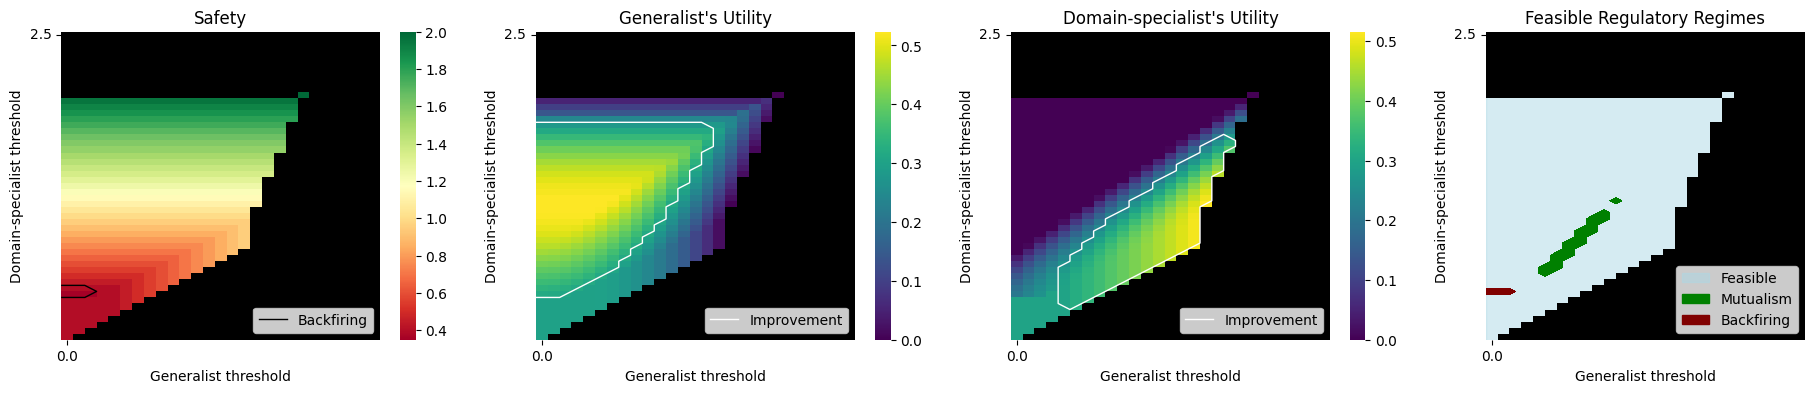

In [316]:
make_four_panel_plot(beta_1_values_pos25, U_G_values_pos25, U_D_values_pos25, ThetaDs_pos25, ThetaGs_pos25)#, savefile='positive_crossterms_fourpanel_june5.png')


0.6666666666666666


/var/folders/35/rbf5cr3s6wx53bzp489khqh40000gn/T/ipykernel_10423/137643727.py:51: UserWarning: The following kwargs were not used by contour: 'label'
  ax[0].contour(backfiring_data, colors='black', levels=[0], linewidths=1, label='Backfiring')
/var/folders/35/rbf5cr3s6wx53bzp489khqh40000gn/T/ipykernel_10423/137643727.py:74: UserWarning: The following kwargs were not used by contour: 'label'
  ax[1].contour(improvement_data, colors='white', levels=[0.0], linewidths=1, label='Improvement')
/var/folders/35/rbf5cr3s6wx53bzp489khqh40000gn/T/ipykernel_10423/137643727.py:95: UserWarning: The following kwargs were not used by contour: 'label'
  ax[2].contour(improvement_data, colors='white', levels=[0.0], linewidths=1, label='Improvement')
/var/folders/35/rbf5cr3s6wx53bzp489khqh40000gn/T/ipykernel_10423/137643727.py:125: UserWarning: The following kwargs were not used by contour: 'label'
  ax[3].contourf(pivot_data_pareto, colors='green', levels=[0.5,1], label='Mutualism')
/var/folders/35/rbf

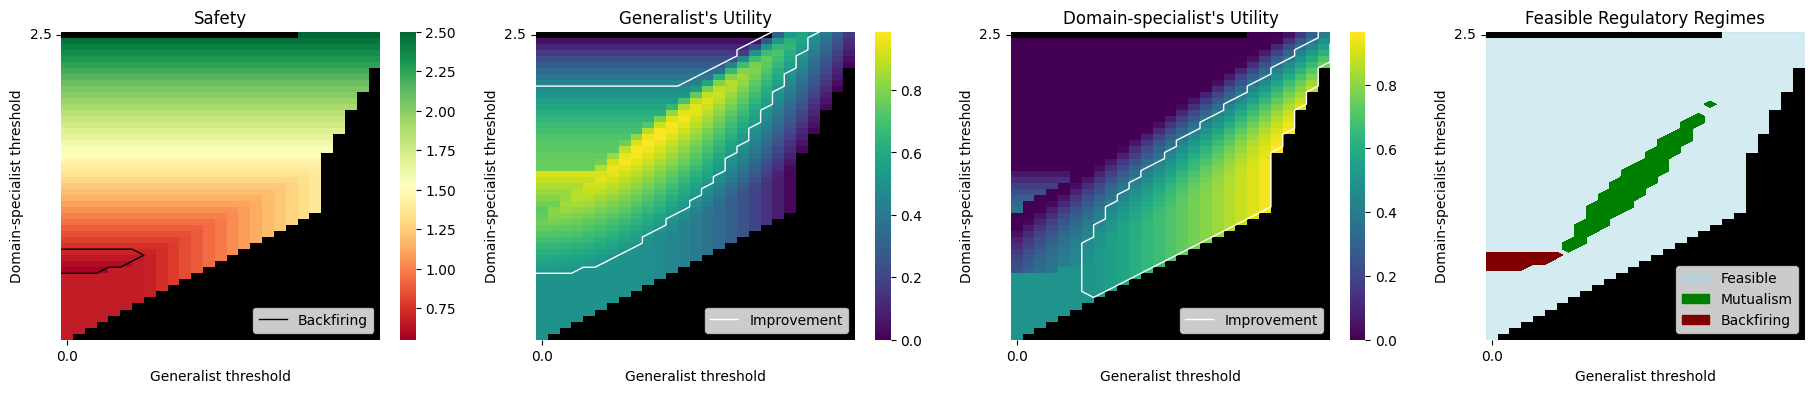

In [317]:
make_four_panel_plot(beta_1_values_neg25, U_G_values_neg25, U_D_values_neg25, ThetaDs_neg25, ThetaGs_neg25)#, savefile='positive_crossterms_fourpanel_june5.png')


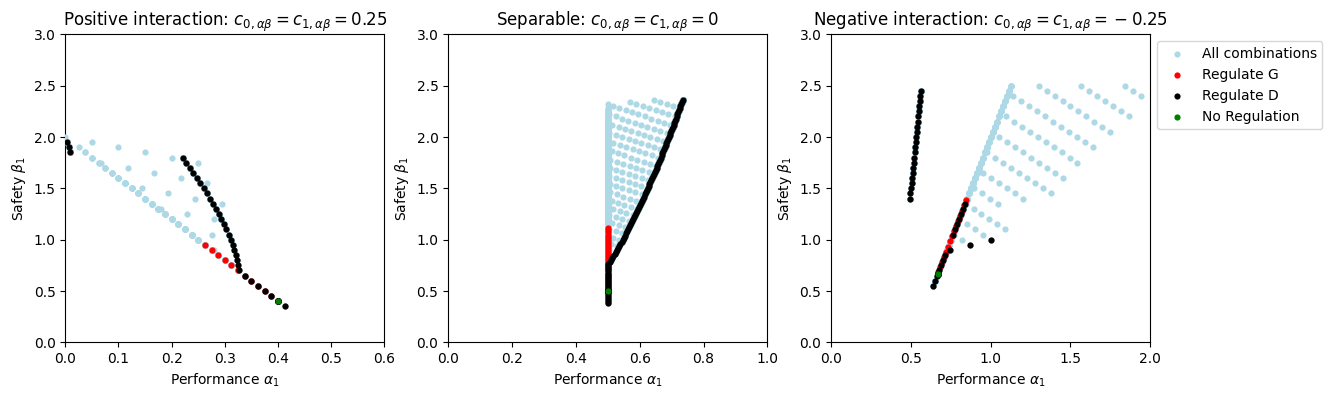

In [431]:
# Plot all attainable beta_0, beta_1 pairs
fig, ax =plt.subplots(1, 3, figsize=[14,4])

def plot_attributes(dataset, ax, size=20):
    ax.scatter(dataset['alpha_1'],dataset['beta_1'],linewidth=0,label='All combinations',color='lightblue', s=size, zorder = 100)
    ax.scatter(dataset[dataset['theta']==dataset['thetaG']]['alpha_1'],dataset[dataset['theta']==dataset['thetaG']]['beta_1'],linewidth=0,label='Regulate G',color='red', s=size, zorder = 100)
    ax.scatter(dataset[dataset['thetaG']==0]['alpha_1'],dataset[dataset['thetaG']==0]['beta_1'],linewidth=0,label='Regulate D',color='black', s=size, zorder = 100)
    ax.scatter(dataset[(dataset['theta']==0)&(dataset['thetaG']==0)]['alpha_1'],dataset[(dataset['theta']==0)&(dataset['thetaG']==0)]['beta_1'],linewidth=0,label='No Regulation',color='green', s=size, zorder = 100)
    ax.set_xlabel('Performance $\\alpha_1$')

plot_attributes(ct_pos_25, ax[0])
plot_attributes(separable, ax[1])
plot_attributes(ct_neg_25, ax[2])

#plot_attributes(ct_pos_75, ax[1])
#plot_attributes(ct_pos_125, ax[2])

ax[0].set_title('Positive interaction: $c_{0,\\alpha\\beta}=c_{1,\\alpha\\beta}=0.25$')
ax[1].set_title('Separable: $c_{0,\\alpha\\beta}=c_{1,\\alpha\\beta}=0$')
ax[2].set_title('Negative interaction: $c_{0,\\alpha\\beta}=c_{1,\\alpha\\beta}=-0.25$')

ax[0].set_xlabel('Performance $\\alpha_1$')
ax[0].set_ylabel('Safety $\\beta_1$')
ax[1].set_ylabel('Safety $\\beta_1$')
ax[2].set_ylabel('Safety $\\beta_1$')
ax[2].legend(bbox_to_anchor=[1,1])

ax[2].set_xlim([0,2])
ax[2].set_ylim([0,3])
ax[1].set_xlim([0,1])
ax[1].set_ylim([0,3])
ax[0].set_xlim([0,.6])
ax[0].set_ylim([0,3])


In [45]:
negative_crossterms[(negative_crossterms['alpha_1']>0.75)&(negative_crossterms['thetaG']==0)]

,Unnamed: 0,C0,C1,r,delta,theta,thetaG,alpha_0,alpha_1,beta_1,U_G,U_D,Gstrategy,Dstrategy,backfiring_flag,beta_0
44,44,[[ 1. -0.1]\n [-0.1 1. ]],[[ 1. -0.1]\n [-0.1 1. ]],[1 1],0.5,0.88,0.0,0.440313,0.778313,0.88,0.635281,0.000002,"$U_D=0, \beta_0=\theta_G$","constrained $\beta_1=max(\beta_0,\theta)$",0.0,0.000001
45,45,[[ 1. -0.1]\n [-0.1 1. ]],[[ 1. -0.1]\n [-0.1 1. ]],[1 1],0.5,0.90,0.0,0.488801,0.828801,0.90,0.625474,0.000002,"$U_D=0, \beta_0=\theta_G$","constrained $\beta_1=max(\beta_0,\theta)$",0.0,0.000001


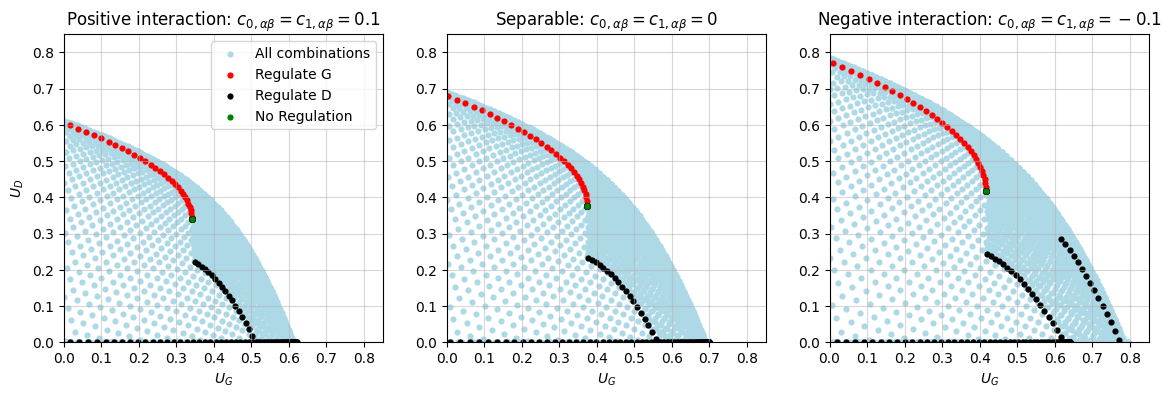

In [430]:
# Plot all attainable U_G, U_D pairs
fig, ax = plt.subplots(1, 3, figsize=[14,4])

def plot_utilities(dataset, ax):
    ax.scatter(dataset['U_G'],dataset['U_D'],linewidth=0,label='All combinations',color='lightblue', s=20, zorder = 1)
    ax.scatter(dataset[dataset['theta']==dataset['thetaG']]['U_G'],dataset[dataset['theta']==dataset['thetaG']]['U_D'],linewidth=0,label='Regulate G',color='red', s=20, zorder = 1)
    ax.scatter(dataset[dataset['thetaG']==0]['U_G'],dataset[dataset['thetaG']==0]['U_D'],linewidth=0,label='Regulate D',color='black', s=20, zorder = 1)
    ax.scatter(dataset[(dataset['theta']==0)&(dataset['thetaG']==0)]['U_G'],dataset[(dataset['theta']==0)&(dataset['thetaG']==0)]['U_D'],linewidth=0,label='No Regulation',color='green', s=20, zorder = 1)
    ax.set_xlabel('$U_G$')

    # Set the lower limit of the y axis to 0
    ax.set_ylim([0,.85])
    ax.set_xlim([0,.85])
    ax.set_xticks([0,.1,.2,.3,.4,.5,.6,.7,.8])

plot_utilities(positive_crossterms, ax[0])
plot_utilities(separable, ax[1])
plot_utilities(negative_crossterms, ax[2])

ax[0].set_title('Positive interaction: $c_{0,\\alpha\\beta}=c_{1,\\alpha\\beta}=0.1$')
ax[1].set_title('Separable: $c_{0,\\alpha\\beta}=c_{1,\\alpha\\beta}=0$')
ax[2].set_title('Negative interaction: $c_{0,\\alpha\\beta}=c_{1,\\alpha\\beta}=-0.1$')

ax[0].set_xlabel('$U_G$')
ax[0].set_ylabel('$U_D$')
ax[0].legend()

ax[0].grid(zorder=0, alpha=0.5)
ax[1].grid(zorder=0, alpha=0.5)
ax[2].grid(zorder=0, alpha=0.5)

#plt.savefig('all_attainable_utilities_nobargaining_crossterms.png', dpi=300, bbox_inches='tight')

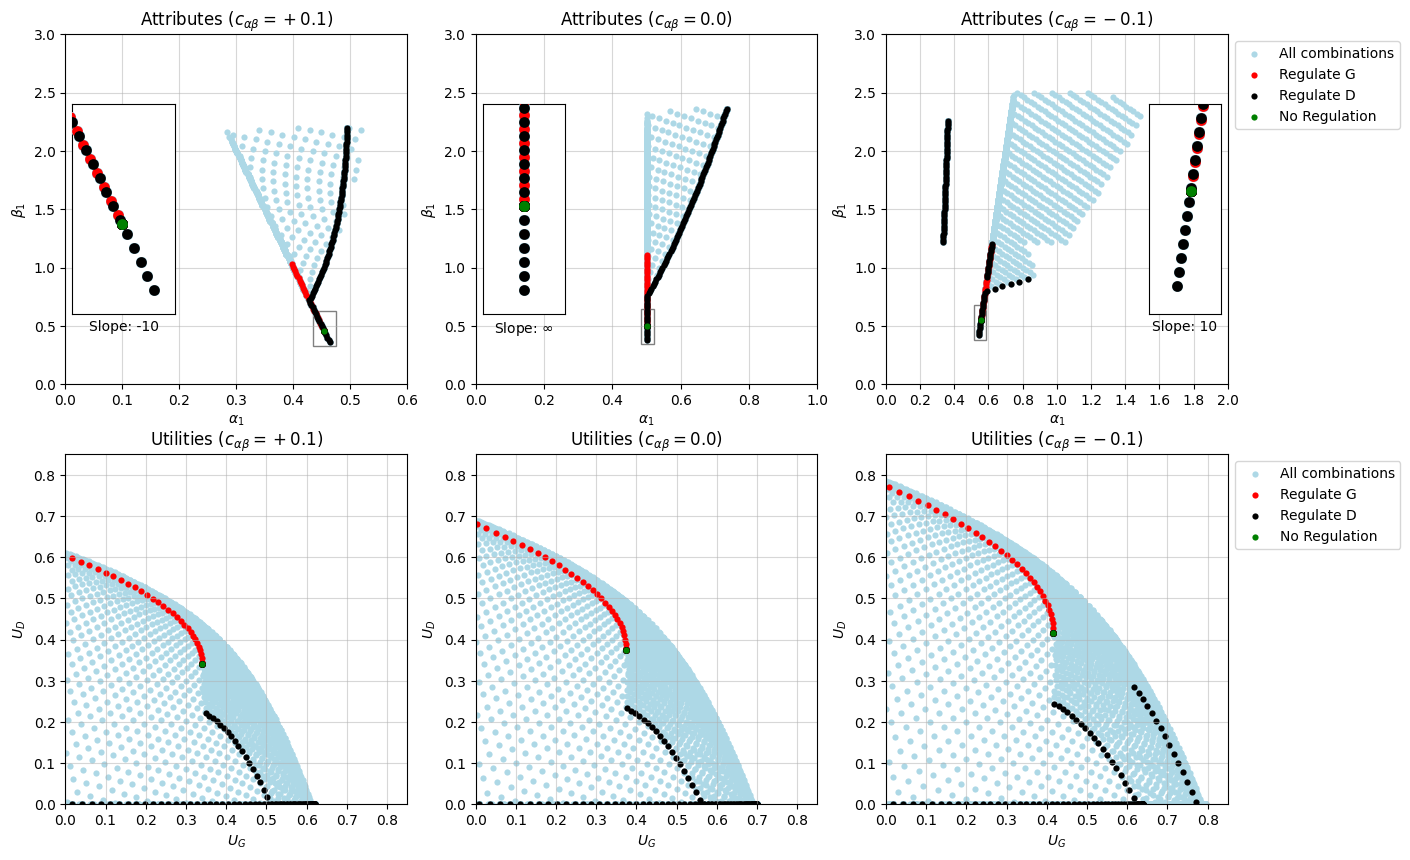

In [470]:
# Plot a 3x2 grid of the above two plots
fig, ax =plt.subplots(2, 3, figsize=[15,10])

def plot_attributes(dataset, ax, size=20):
    ax.scatter(dataset['alpha_1'],dataset['beta_1'],linewidth=0,label='All combinations',color='lightblue', s=size, zorder = 100)
    ax.scatter(dataset[dataset['theta']==dataset['thetaG']]['alpha_1'],dataset[dataset['theta']==dataset['thetaG']]['beta_1'],linewidth=0,label='Regulate G',color='red', s=size, zorder = 100)
    ax.scatter(dataset[dataset['thetaG']==0]['alpha_1'],dataset[dataset['thetaG']==0]['beta_1'],linewidth=0,label='Regulate D',color='black', s=size, zorder = 100)
    ax.scatter(dataset[(dataset['theta']==0)&(dataset['thetaG']==0)]['alpha_1'],dataset[(dataset['theta']==0)&(dataset['thetaG']==0)]['beta_1'],linewidth=0,label='No Regulation',color='green', s=size, zorder = 100)
    ax.set_xlabel('$\\alpha_1$')
    ax.grid(alpha=0.5)

plot_attributes(positive_crossterms, ax[0,0])
plot_attributes(separable, ax[0,1])
plot_attributes(negative_crossterms, ax[0,2])

#plot_attributes(ct_pos_75, ax[1])
#plot_attributes(ct_pos_125, ax[2])

ax[0,0].set_title('Attributes ($c_{\\alpha\\beta}=+0.1$)')
ax[0,1].set_title('Attributes ($c_{\\alpha\\beta}=0.0$)')
ax[0,2].set_title('Attributes ($c_{\\alpha\\beta}=-0.1$)')

ax[0,0].set_xlabel('$\\alpha_1$')
ax[0,0].set_ylabel('$\\beta_1$')
ax[0,1].set_ylabel('$\\beta_1$')
ax[0,2].set_ylabel('$\\beta_1$')
ax[0,2].legend(bbox_to_anchor=[1,1])

ax[0,2].set_xticks([0,.2,.4,.6,.8,1,1.2,1.4,1.6,1.8,2])

from mpl_toolkits.axes_grid1.inset_locator import zoomed_inset_axes, mark_inset

axins = zoomed_inset_axes(ax[0,0], loc=6, zoom=6)  # zoom factor of 3, location upper right
plot_attributes(positive_crossterms, axins,size=20*3)
axins.set_xlim(0.44, 0.47)
axins.set_ylim(0.325, 0.625)
axins.set_xticks([])#[0.44, 0.45, 0.46, 0.47])
axins.set_yticks([])#[0.4,.5])
axins.set_xlabel("Slope: -10")
axins.grid()
from matplotlib.patches import Rectangle
rect = Rectangle((0.435, 0.325), 0.04, 0.3, linewidth=1, edgecolor='gray', facecolor='none')
ax[0,0].add_patch(rect)

axins = zoomed_inset_axes(ax[0,1], loc=6, zoom=6)  # zoom factor of 3, location upper right
plot_attributes(separable, axins,size=20*3)
# Set the limits for the zoom-in region
axins.set_xlim(.5-0.02,.5+0.02) #(0.475, 0.525)
axins.set_ylim(0.325+.02, 0.625+.02)
axins.set_xticks([])
axins.set_yticks([])
axins.set_xlabel("Slope: $\infty$")
axins.grid()
rect = Rectangle((.5-0.0175, 0.325+.02), 0.02*2, 0.3, linewidth=1, edgecolor='gray', facecolor='none')
ax[0,1].add_patch(rect)

axins = zoomed_inset_axes(ax[0,2], loc=5, zoom=6)  # zoom factor of 3, location upper right
plot_attributes(negative_crossterms, axins,size=20*3)
axins.set_xlim(0.515, 0.585)
axins.set_ylim(0.38, 0.68)
axins.set_xticks([])
axins.set_yticks([])
axins.set_xlabel("Slope: 10")
axins.grid()
rect = Rectangle((0.515, 0.38), 0.07, 0.3, linewidth=1, edgecolor='gray', facecolor='none')
ax[0,2].add_patch(rect)

ax[0,2].set_xlim([0,2])
ax[0,2].set_ylim([0,3])
ax[0,1].set_xlim([0,1])
ax[0,1].set_ylim([0,3])
ax[0,0].set_xlim([0,.6])
ax[0,0].set_ylim([0,3])




def plot_utilities(dataset, ax):
    ax.scatter(dataset['U_G'],dataset['U_D'],linewidth=0,label='All combinations',color='lightblue', s=20, zorder = 1)
    ax.scatter(dataset[dataset['theta']==dataset['thetaG']]['U_G'],dataset[dataset['theta']==dataset['thetaG']]['U_D'],linewidth=0,label='Regulate G',color='red', s=20, zorder = 1)
    ax.scatter(dataset[dataset['thetaG']==0]['U_G'],dataset[dataset['thetaG']==0]['U_D'],linewidth=0,label='Regulate D',color='black', s=20, zorder = 1)
    ax.scatter(dataset[(dataset['theta']==0)&(dataset['thetaG']==0)]['U_G'],dataset[(dataset['theta']==0)&(dataset['thetaG']==0)]['U_D'],linewidth=0,label='No Regulation',color='green', s=20, zorder = 1)
    ax.set_xlabel('$U_G$')
    ax.set_ylabel('$U_D$')

    # Set the lower limit of the y axis to 0
    ax.set_ylim([0,.85])
    ax.set_xlim([0,.85])
    ax.set_xticks([0,.1,.2,.3,.4,.5,.6,.7,.8])


plot_utilities(positive_crossterms, ax[1,0])
plot_utilities(separable, ax[1,1])
plot_utilities(negative_crossterms, ax[1,2])

ax[1,0].set_title('Utilities ($c_{\\alpha\\beta}=+0.1$)')
ax[1,1].set_title('Utilities ($c_{\\alpha\\beta}=0.0$)')
ax[1,2].set_title('Utilities ($c_{\\alpha\\beta}=-0.1$)')

ax[1,0].set_xlabel('$U_G$')
ax[1,0].set_ylabel('$U_D$')
ax[1,2].legend(bbox_to_anchor=[1.525,1])

ax[1,0].grid(zorder=0, alpha=0.5)
ax[1,1].grid(zorder=0, alpha=0.5)
ax[1,2].grid(zorder=0, alpha=0.5)


plt.savefig('all_attainable_utilities_nobargaining_crossterms_june9.png', dpi=300, bbox_inches='tight')



In [433]:
ax[1].scatter(separable['alpha_1'],separable['beta_1'],linewidth=0,label='All combinations',color='lightblue')
ax[1].scatter(separable[separable['theta']==separable['thetaG']]['alpha_1'],separable[separable['theta']==separable['thetaG']]['beta_1'],linewidth=0,label='Regulate G',color='red')
ax[1].scatter(separable[separable['thetaG']==0]['alpha_1'],separable[separable['thetaG']==0]['beta_1'],linewidth=0,label='Regulate D',color='blue')
ax[1].scatter(separable[(separable['theta']==0)&(separable['thetaG']==0)]['alpha_1'],separable[(separable['theta']==0)&(separable['thetaG']==0)]['beta_1'],linewidth=0,label='No Regulation',color='green')

ax[1].set_xlabel('Performance $\\alpha_1$')
ax[1].set_ylabel('Safety $\\beta_1$')
ax[1].set_xlim([0,0.8])
ax[1].set_ylim([0,2.5])
ax[1].legend()